# Versuch 2 (guided by Claude AI)

## Vorgehen:
- 1: Daten laden & erkunden
- 2: Verteilungen & Visualisierung
- 3: Statistisches Testen
- 4: Dimensiosreduktion & Muster
- 5: Forschungsfrage entwickeln


## 1: Daten laden & erkunden


In [ ]:
 #1.1 Datensatz laden und Grundstruktur prüfen
import pandas as pd
df = pd.read_csv("C:\\Users\\niels\\OneDrive\\ETH\\FS26\\Foundations of Data Science\\Group Project\\TCGA\\dataset.csv", index_col=0)

df.shape

(1218, 16383)

In [ ]:
df.dtypes

ARHGEF10L    float64
HIF3A        float64
RNF17        float64
RNF10        float64
RNF11        float64
              ...   
MED16        float64
HCG27        float64
CYP2A13      float64
CCR10        float64
KDM4D        float64
Length: 16383, dtype: object

In [ ]:
df.columns

Index(['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'GTF2IP1',
       'REM1', 'MTVR2', 'RTN4RL2',
       ...
       'OR51A7', 'WT1', 'RNF24', 'MED15', 'ZIC5', 'MED16', 'HCG27', 'CYP2A13',
       'CCR10', 'KDM4D'],
      dtype='str', length=16383)

In [ ]:
df.head(20)

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,OR51A7,WT1,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,...,0.0,3.1616,7.8109,11.6239,4.8736,10.7543,3.2396,0.0000,3.9455,4.9909
TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854,...,0.0,0.3459,9.9935,10.3422,5.0067,8.9546,2.4151,0.0000,1.6630,5.7206
TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329,...,0.0,4.3645,8.2866,11.0562,0.0000,10.3913,2.6166,0.0000,4.8579,5.1699
TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308,...,0.0,5.0536,8.7778,10.4420,0.0000,9.6572,4.0637,1.5447,2.0242,6.1611
TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505,...,0.0,3.8982,7.6201,10.0268,0.0000,9.6684,2.8988,0.0000,3.3135,3.9455
TCGA-A8-A096-01,9.7665,0.2738,0.8765,11.8118,10.8554,10.4282,12.4810,4.3232,0.0000,5.0156,...,0.0,4.6815,7.8086,11.0203,0.0000,10.2189,3.5172,0.0000,2.6380,5.1659
TCGA-BH-A0C7-01,10.0931,3.6090,0.0000,11.3820,10.7663,10.3366,12.7240,2.2163,0.3340,5.0910,...,0.0,5.2575,7.8006,9.9458,6.4553,9.8517,5.1557,0.3340,3.5460,5.1129
TCGA-AC-A5XU-01,9.1524,0.4738,0.0000,11.5004,10.4358,10.4248,13.7292,5.8810,0.0000,5.9552,...,0.0,4.2091,7.6885,10.8724,0.0000,10.6597,5.0895,0.0000,4.7984,3.7063
TCGA-PE-A5DE-01,9.9398,2.9378,0.0000,12.2055,11.2210,9.8265,12.2089,4.4802,0.0000,5.0818,...,0.0,1.4733,8.5386,11.5637,0.0000,10.6175,4.5639,0.0000,4.8790,4.0483
TCGA-PE-A5DC-01,9.6287,4.1136,0.0000,12.1312,10.8013,10.3031,12.4242,5.9430,1.1939,5.8169,...,0.0,1.6536,9.0908,10.6021,3.3845,10.7327,5.7379,0.5152,4.8095,3.8812


In [ ]:
#1.2 Outcome-Datei einlesen und Grundstruktur prüfen
outcome = pd.read_csv("C:\\Users\\niels\\OneDrive\\ETH\\FS26\\Foundations of Data Science\\Group Project\\TCGA\\outcome.csv")

outcome.shape

(1218, 2)

In [ ]:
#Outcome mit Expressionsdaten verknüpfen
combined = df.join(outcome)

combined.head(10)

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D,Unnamed: 0,BRCA_subtype
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,...,7.8109,11.6239,4.8736,10.7543,3.2396,0.0000,3.9455,4.9909,NaN,NaN
TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854,...,9.9935,10.3422,5.0067,8.9546,2.4151,0.0000,1.6630,5.7206,NaN,NaN
TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329,...,8.2866,11.0562,0.0000,10.3913,2.6166,0.0000,4.8579,5.1699,NaN,NaN
TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308,...,8.7778,10.4420,0.0000,9.6572,4.0637,1.5447,2.0242,6.1611,NaN,NaN
TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505,...,7.6201,10.0268,0.0000,9.6684,2.8988,0.0000,3.3135,3.9455,NaN,NaN
TCGA-A8-A096-01,9.7665,0.2738,0.8765,11.8118,10.8554,10.4282,12.4810,4.3232,0.0000,5.0156,...,7.8086,11.0203,0.0000,10.2189,3.5172,0.0000,2.6380,5.1659,NaN,NaN
TCGA-BH-A0C7-01,10.0931,3.6090,0.0000,11.3820,10.7663,10.3366,12.7240,2.2163,0.3340,5.0910,...,7.8006,9.9458,6.4553,9.8517,5.1557,0.3340,3.5460,5.1129,NaN,NaN
TCGA-AC-A5XU-01,9.1524,0.4738,0.0000,11.5004,10.4358,10.4248,13.7292,5.8810,0.0000,5.9552,...,7.6885,10.8724,0.0000,10.6597,5.0895,0.0000,4.7984,3.7063,NaN,NaN
TCGA-PE-A5DE-01,9.9398,2.9378,0.0000,12.2055,11.2210,9.8265,12.2089,4.4802,0.0000,5.0818,...,8.5386,11.5637,0.0000,10.6175,4.5639,0.0000,4.8790,4.0483,NaN,NaN
TCGA-PE-A5DC-01,9.6287,4.1136,0.0000,12.1312,10.8013,10.3031,12.4242,5.9430,1.1939,5.8169,...,9.0908,10.6021,3.3845,10.7327,5.7379,0.5152,4.8095,3.8812,NaN,NaN


In [ ]:
combined.info()

<class 'pandas.DataFrame'>
Index: 1218 entries, TCGA-AR-A5QQ-01 to TCGA-B6-A0X1-01
Columns: 16385 entries, ARHGEF10L to BRCA_subtype
dtypes: float64(16172), int64(211), str(2)
memory usage: 152.3+ MB


In [ ]:
df.nunique()

ARHGEF10L    1190
HIF3A        1174
RNF17         287
RNF10        1153
RNF11        1183
             ... 
MED16        1177
HCG27        1197
CYP2A13       419
CCR10        1199
KDM4D        1191
Length: 16383, dtype: int64

In [ ]:
#1.3 Fehlende Werte & Qualitätskontrolle
combined.isna().sum().sum()

np.int64(2449)

In [ ]:
combined.duplicated().sum()

np.int64(0)

In [ ]:
#anteil NUllwerte pro Gen
zero_fraction = (df==0).mean(axis=0)
print(zero_fraction.describe())

count    16383.000000
mean         0.139946
std          0.295732
min          0.000000
25%          0.000000
50%          0.000000
75%          0.040230
max          1.000000
dtype: float64


In [ ]:
#Gene mit mehr als 50% Nullwerten entfernen
high_zero_genes = zero_fraction[zero_fraction > 0.5]
print(high_zero_genes)

RNF17        0.764368
MTVR2        0.582923
C16orf11     0.665846
LOC339240    0.868637
LRRTM1       0.523810
               ...   
C6orf10      0.852217
DISC2        0.661741
OR51A7       0.994253
ZIC5         0.502463
CYP2A13      0.650246
Length: 2235, dtype: float64


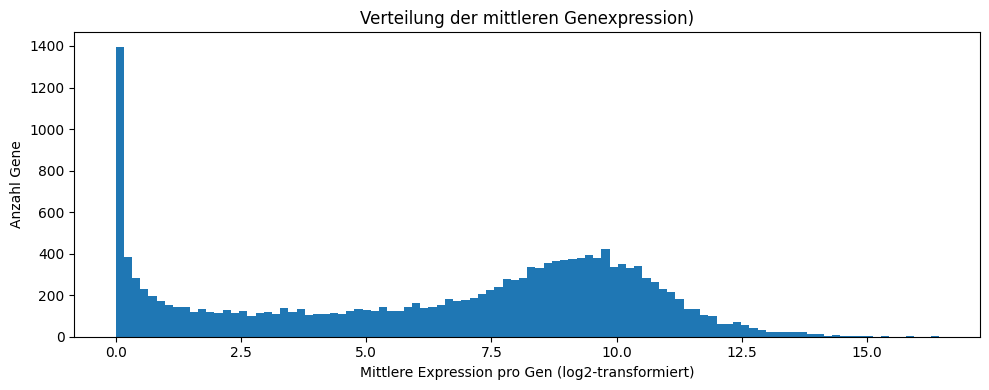

In [ ]:
#Histogramm mit mittlerer Expression pro Gen
import matplotlib.pyplot as plt
mean_expression = df.mean(axis=0)

plt.figure(figsize=(10, 4))
plt.hist(mean_expression, bins = 100)
plt.xlabel("Mittlere Expression pro Gen (log2-transformiert)")
plt.ylabel("Anzahl Gene")
plt.title("Verteilung der mittleren Genexpression")
plt.tight_layout()
plt.show()

In [ ]:
#Gene mit nahezu null Varianz identifizieren
gene_variance = df.var(axis=0)

#Schwellwert definieren
threshold = 0.1
low_var_genes = gene_variance[gene_variance < threshold]
print(f"Gene mit Varianz < {threshold}: {len(low_var_genes)}")

Gene mit Varianz < 0.1: 1112


## 2: Verteilugen & Visualisierung

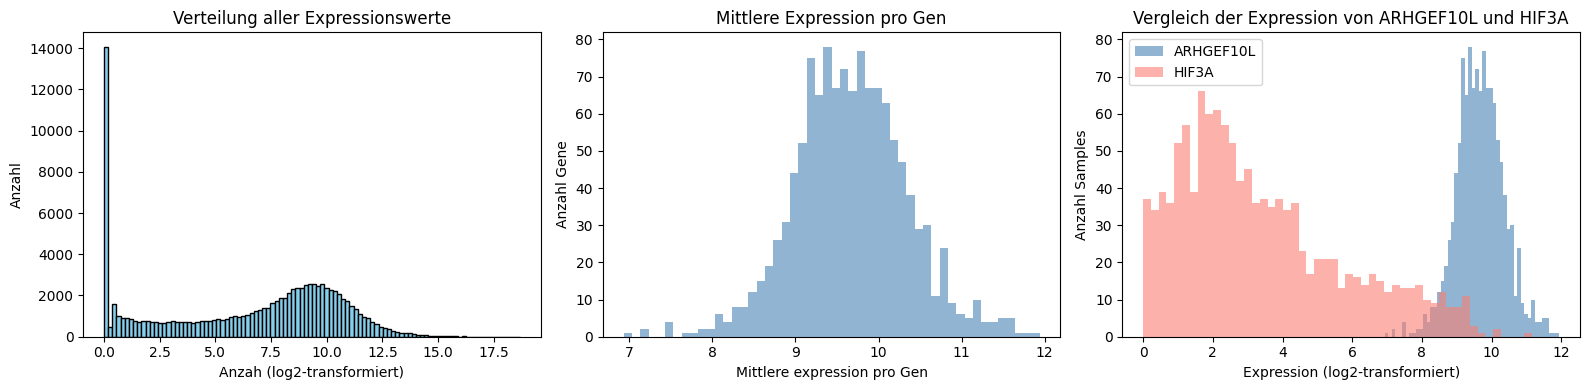

In [ ]:
#2.1 Expressionsverteilung visualisieren
import seaborn as sns
import numpy as np

gene1 = df.columns[0]
gene2 = df.columns[1]

#1. Histogramm aller Expressionswerte
fig, axes = plt.subplots(1, 3, figsize = (16,4))

#alle Werte als flaches Array (stichprobe wegen Grösse)
all_values = df.values.flatten()
sample_values = np.random.choice(all_values, size=100000, replace=False)

axes[0].hist(sample_values, bins=100, color='skyblue', edgecolor='black')
axes[0].set_xlabel("Anzah (log2-transformiert)")
axes[0].set_ylabel("Anzahl")
axes[0].set_title("Verteilung aller Expressionswerte")

#2. MIttlere Expression pro Gen
mean_expression = df.mean(axis=0)
axes[1].hist(df[gene1], bins = 50, alpha = 0.6, label=gene1, color="steelblue")
axes[1].set_xlabel("Mittlere expression pro Gen")
axes[1].set_ylabel("Anzahl Gene")
axes[1].set_title("Mittlere Expression pro Gen")

#3. Zwei einzelne Gene Vergleichen
gene1 = df.columns[0]
gene2 = df.columns[1]

axes[2].hist(df[gene1], bins = 50, alpha = 0.6, label=gene1, color="steelblue")
axes[2].hist(df[gene2], bins = 50, alpha = 0.6, label=gene2, color="salmon")
axes[2].set_xlabel("Expression (log2-transformiert)")
axes[2].set_ylabel("Anzahl Samples")
axes[2].set_title(f"Vergleich der Expression von {gene1} und {gene2}")
axes[2].legend()

plt.tight_layout()
plt.show()

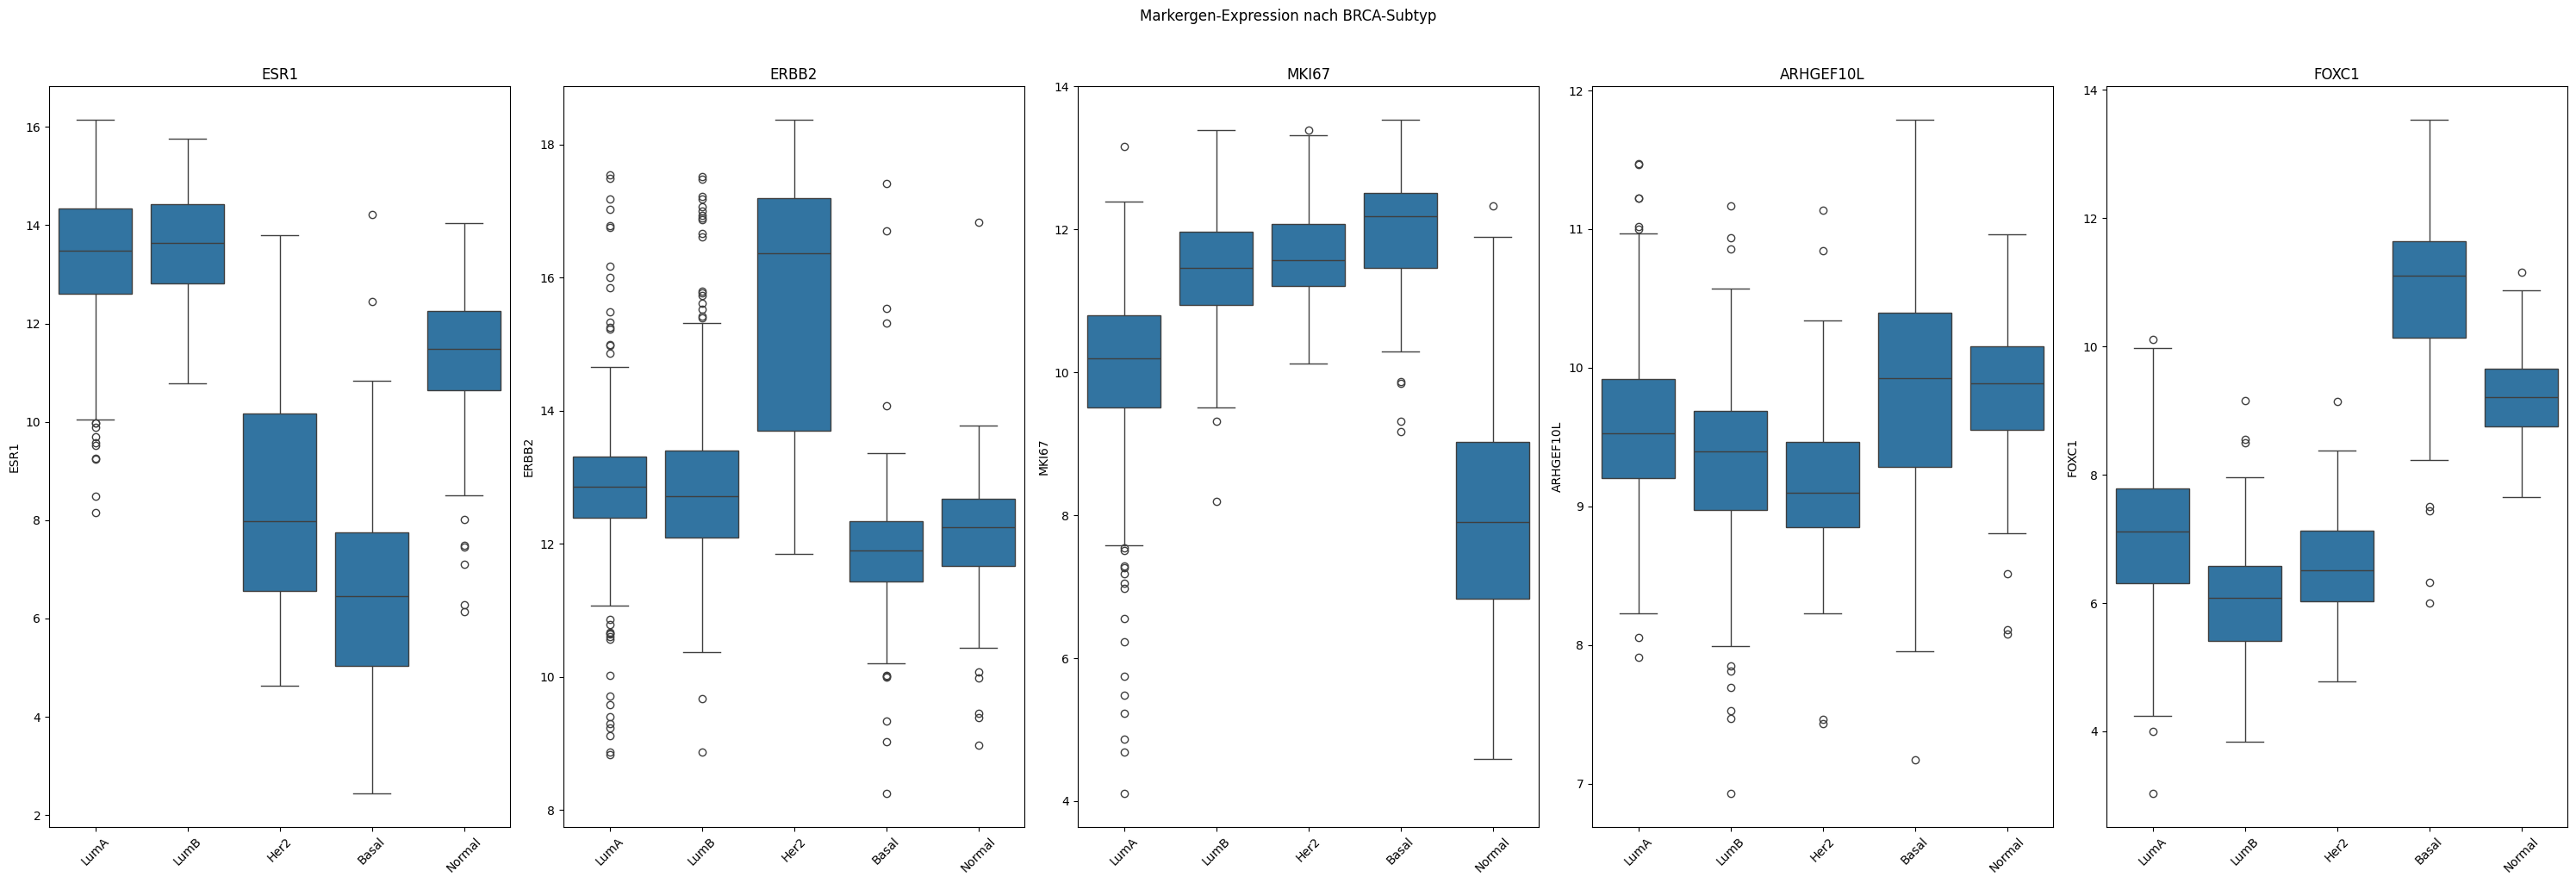

In [ ]:
#2.2 Subtypverfleich mit Boxplots
marker_genes = ['ESR1', 'ERBB2', 'MKI67', 'ARHGEF10L', 'FOXC1']

# Nur Samples mit bekanntem Subtyp verwenden
combined = df.join(outcome.set_index('Unnamed: 0'))

combined_labeled = combined.dropna(subset=['BRCA_subtype'])

fig, axes = plt.subplots(1, len(marker_genes), figsize=(30, 10))

for ax, gene in zip(axes, marker_genes):
    if gene not in combined_labeled.columns:
        print(f"Gen {gene} nicht im Datensatz gefunden")
        continue
    sns.boxplot(
        data=combined_labeled,
        x='BRCA_subtype',
        y=gene,
        ax=ax,
        order=['LumA', 'LumB', 'Her2', 'Basal', 'Normal']
    )
    ax.set_title(gene)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Markergen-Expression nach BRCA-Subtyp', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\niels\AppData\Local\Temp\ipykernel_36692\719823502.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Subtyp', bbox_to_anchor=(1.15, 1), loc='upper right')


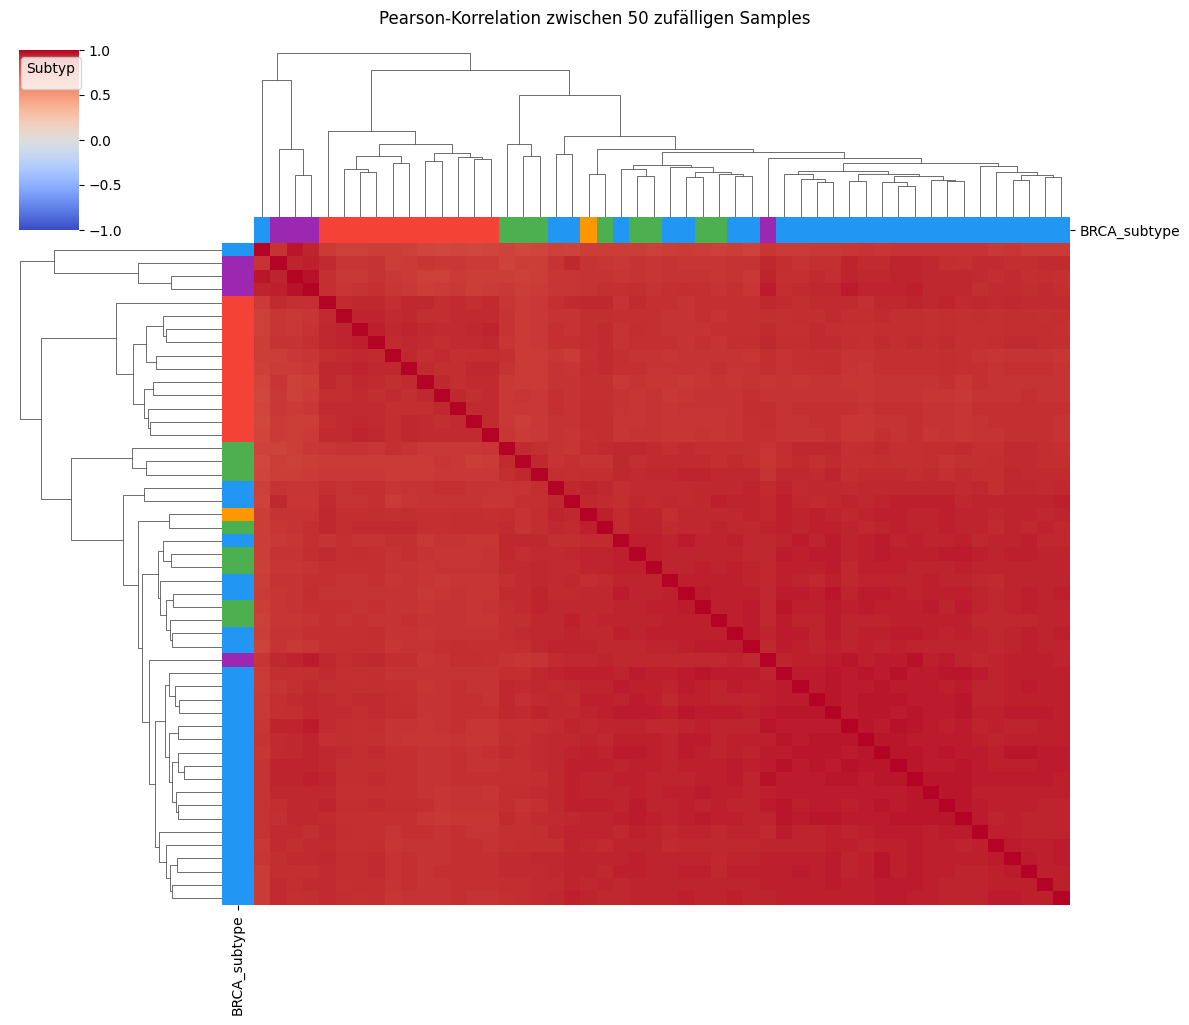

In [ ]:
#2.3 Clustermap der Pearson-Korrelation
# Samples nach Subtyp sortieren
sample_50 = combined.dropna(subset=['BRCA_subtype']).sample(n=50, random_state=42)
sample_50 = sample_50.sort_values('BRCA_subtype')  # <-- neu

expression_cols = [col for col in sample_50.columns if col != 'BRCA_subtype']
pearson_corr = sample_50[expression_cols].T.corr()

# Farbstreifen für Subtypen
subtype_palette = {
    'LumA': '#2196F3',
    'LumB': '#4CAF50',
    'Her2': '#FF9800',
    'Basal': '#F44336',
    'Normal': '#9C27B0'
}
row_colors = sample_50['BRCA_subtype'].map(subtype_palette)

# Clustermap mit Farbstreifen
sns.clustermap(pearson_corr, 
               cmap='coolwarm', vmin=-1, vmax=1,
               row_colors=row_colors,
               col_colors=row_colors,
               xticklabels=False, yticklabels=False,
               figsize=(12, 10))

plt.suptitle('Pearson-Korrelation zwischen 50 zufälligen Samples', y=1.02)
plt.show()

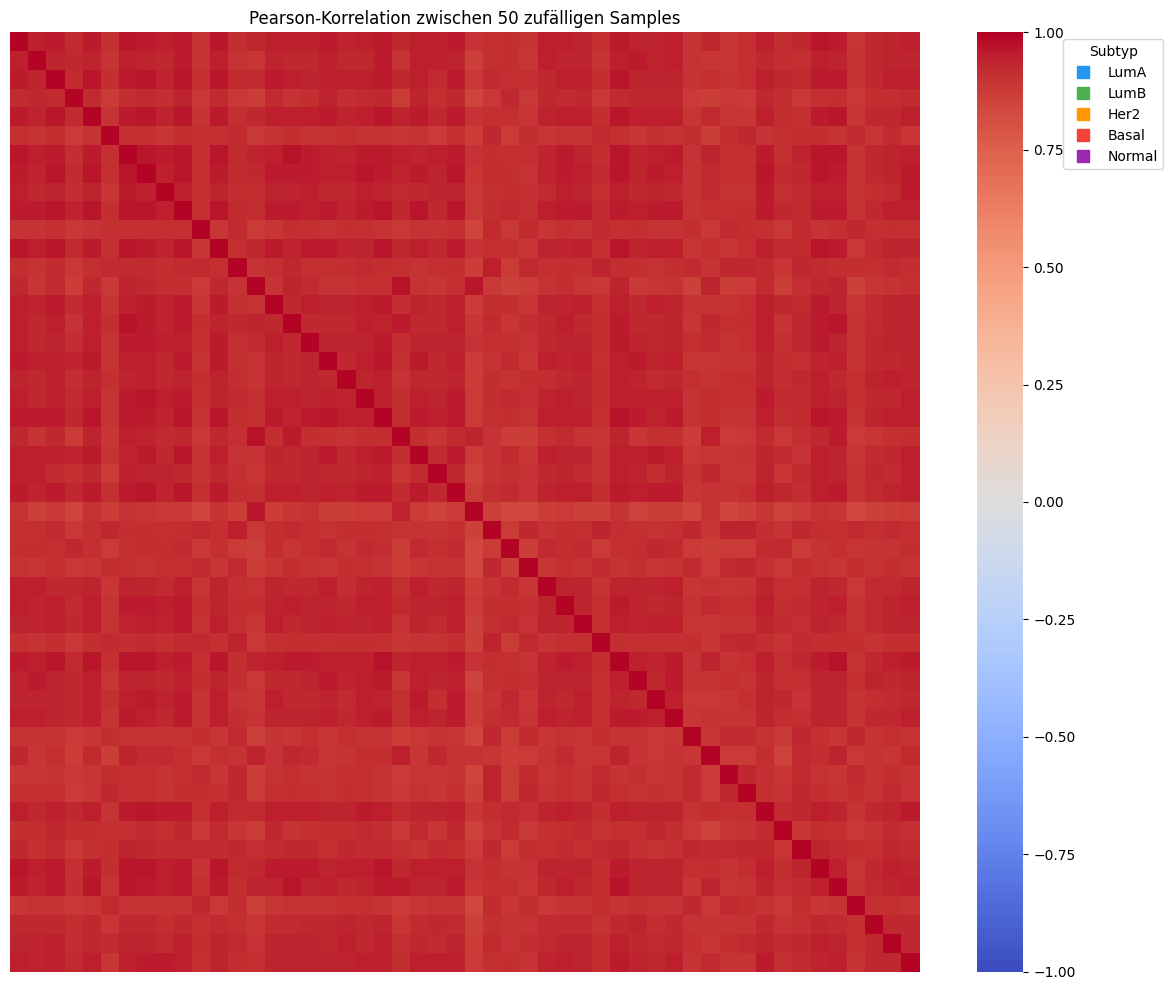

In [ ]:
# 50 zufällige Samples ziehen (nur labeled)
sample_50 = combined.dropna(subset=['BRCA_subtype']).sample(n=50, random_state=42)

# Nur Expressionsspalten für Korrelation verwenden
expression_cols = [col for col in sample_50.columns if col != 'BRCA_subtype']
pearson_corr = sample_50[expression_cols].T.corr()

# Subtyp-Farben für die Achsenbeschriftung
subtype_colors = sample_50['BRCA_subtype'].map({
    'LumA': '#2196F3',
    'LumB': '#4CAF50',
    'Her2': '#FF9800',
    'Basal': '#F44336',
    'Normal': '#9C27B0'
})

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, cmap='coolwarm', vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False)

# Farbbalken für Subtypen als Legende
for subtype, color in {'LumA': '#2196F3', 'LumB': '#4CAF50',
                        'Her2': '#FF9800', 'Basal': '#F44336',
                        'Normal': '#9C27B0'}.items():
    plt.plot([], [], 's', color=color, label=subtype, markersize=8)

plt.legend(title='Subtyp', bbox_to_anchor=(1.15, 1), loc='upper left')
plt.title('Pearson-Korrelation zwischen 50 zufälligen Samples')
plt.tight_layout()
plt.show()

## 3: Statistisches Testen

ARHGEF10L: Shapiro-Wilk W=0.9939, p=6.5179e-05 → nicht normalverteilt
HIF3A: Shapiro-Wilk W=0.9326, p=5.1392e-23 → nicht normalverteilt
RNF17: Shapiro-Wilk W=0.4129, p=1.4877e-52 → nicht normalverteilt


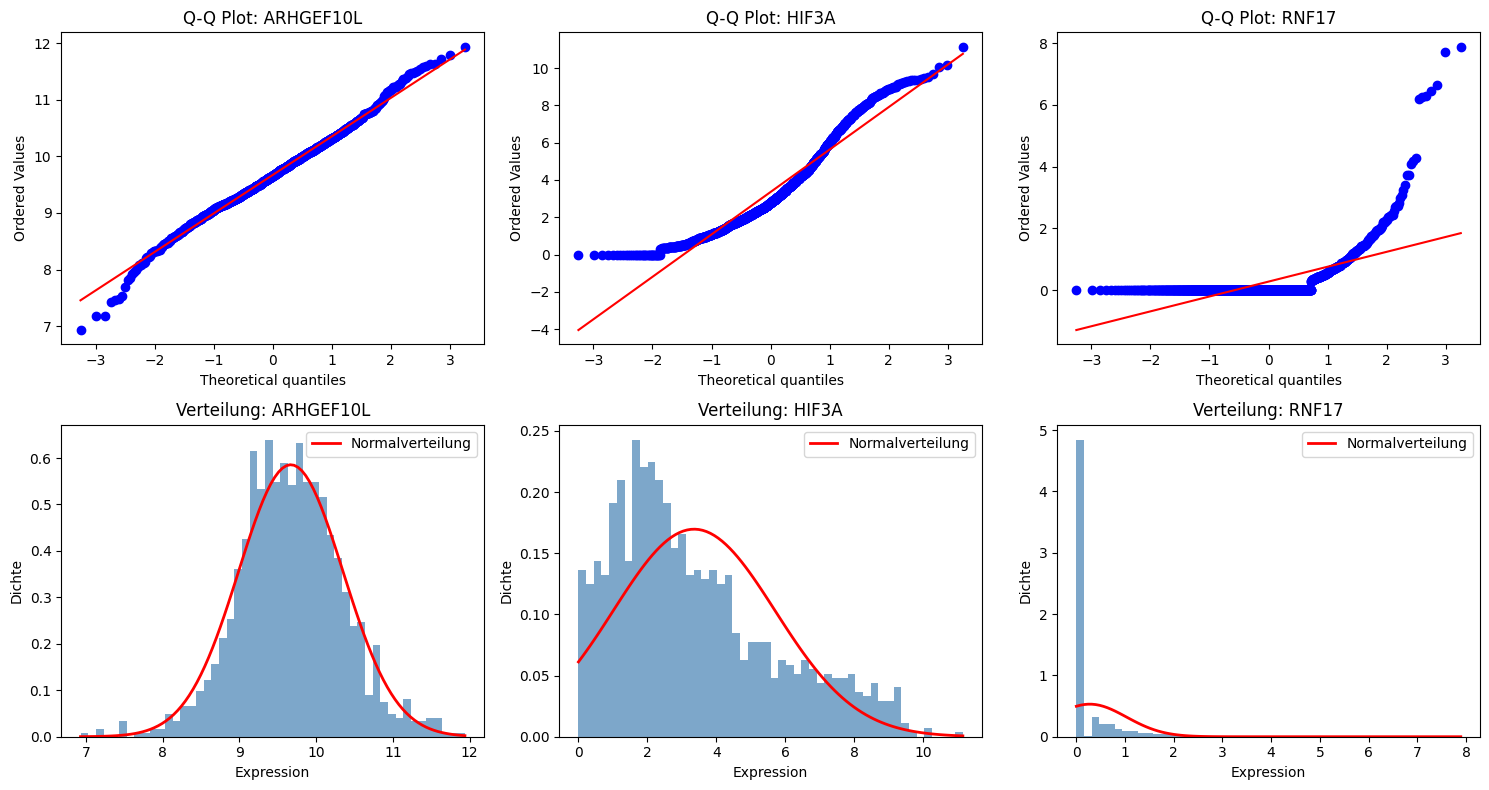

In [ ]:
#3.1 Normalverteilung Prüfen
import scipy.stats as stat

# 3 Gene auswählen
genes = [df.columns[0], df.columns[1], df.columns[2]]
# oder spezifisch: genes = ['ESR1', 'ERBB2', 'MKI67']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, gene in enumerate(genes):
    values = df[gene].dropna()

    # Q-Q Plot
    stat.probplot(values, dist='norm', plot=axes[0, i])
    axes[0, i].set_title(f'Q-Q Plot: {gene}')

    # Histogramm mit Normalverteilungskurve
    axes[1, i].hist(values, bins=50, density=True, 
                    color='steelblue', edgecolor='none', alpha=0.7)
    x = np.linspace(values.min(), values.max(), 100)
    mu, std = values.mean(), values.std()
    axes[1, i].plot(x, stat.norm.pdf(x, mu, std), 
                    color='red', linewidth=2, label='Normalverteilung')
    axes[1, i].set_xlabel('Expression')
    axes[1, i].set_ylabel('Dichte')
    axes[1, i].set_title(f'Verteilung: {gene}')
    axes[1, i].legend()

    # Shapiro-Wilk Test
    shapiro_stat, p = stat.shapiro(values.sample(min(len(values), 5000), random_state=42))
    print(f"{gene}: Shapiro-Wilk W={shapiro_stat:.4f}, p={p:.4e} "
          f"→ {'nicht normalverteilt' if p < 0.05 else 'normalverteilt'}")

plt.tight_layout()
plt.show()

In [ ]:
#3.2 Differentiell exprimierte Gene finden
#t-test zwischen zwei subtypen für jedes Gen
from scipy.stats import mannwhitneyu

group_a = combined[combined["BRCA_subtype"] == "Basal"]
group_b = combined[combined["BRCA_subtype"] == "LumA"]

expression_cols = [col for col in combined.columns if col != "BRCA_subtype"]

pvalues = []
for gene in expression_cols:
    _, p = mannwhitneyu(group_a[gene].dropna(), group_b[gene].dropna())
    pvalues.append(p)

#Korrektur für multiples Testen
from statsmodels.stats.multitest import multipletests
rejected, pvalues_corrected, _, _ = multipletests(pvalues, method="fdr_bh")
print(f"Signifikante Gene (FDR < 0.05): {rejected.sum()} von {len(rejected)}")

#Ergebnisse in einem Dataframe zusammenfassen
results = pd.DataFrame({
    "gene": expression_cols,
    "p_value": pvalues,
    "p_value_corrected": pvalues_corrected,
    "signifikant": rejected
})

results = results.sort_values("p_value_corrected")
print(results.head(10))

Signifikante Gene (FDR < 0.05): 12297 von 16383
          gene       p_value  p_value_corrected  signifikant
726     TBC1D9  4.006137e-69       3.281627e-65         True
9921      ESR1  2.856772e-69       3.281627e-65         True
4579      MLPH  6.414497e-69       3.502957e-65         True
12684    CDC20  2.844313e-68       9.319675e-65         True
13521  C6orf97  2.569050e-68       9.319675e-65         True
8693     TTC36  3.647608e-68       9.959794e-65         True
5471      CA12  7.543631e-68       1.765533e-64         True
362      GPR77  1.548832e-67       3.171813e-64         True
8558    SCUBE2  1.820983e-67       3.314795e-64         True
10574    CDCA8  3.511768e-67       5.753330e-64         True


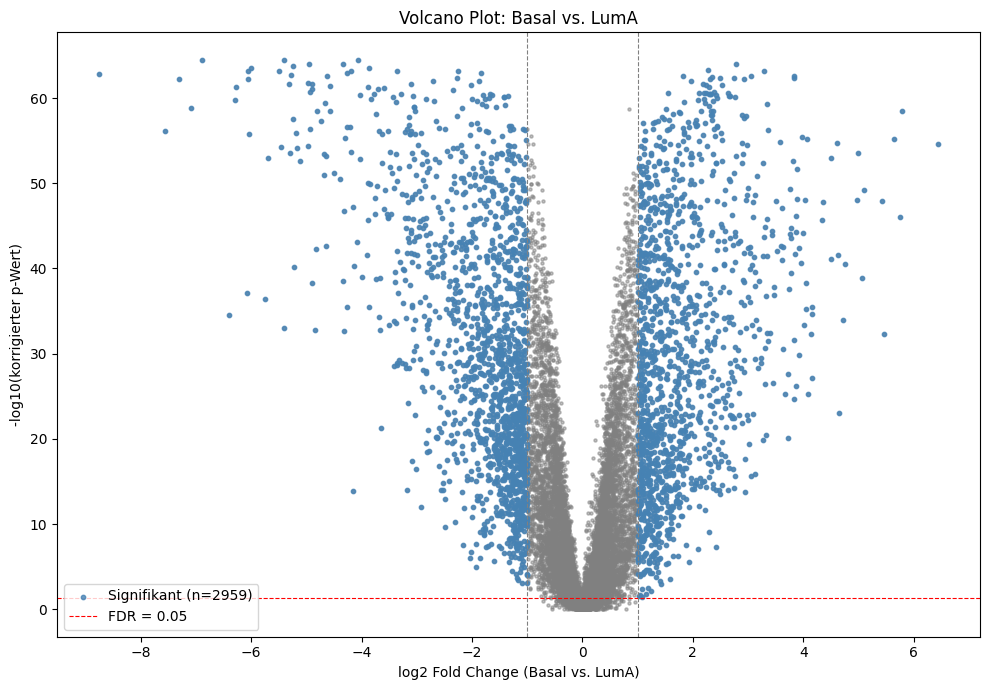

Signifikante Gene mit |FC| > 1: 2959
          gene    log2FC       p_value  p_value_corrected  neg_log10_p
9921      ESR1 -6.891932  2.856772e-69       3.281627e-65    64.483911
726     TBC1D9 -4.073158  4.006137e-69       3.281627e-65    64.483911
4579      MLPH -5.412237  6.414497e-69       3.502957e-65    64.455565
12684    CDC20  2.777041  2.844313e-68       9.319675e-65    64.030599
13521  C6orf97 -4.336914  2.569050e-68       9.319675e-65    64.030599
8693     TTC36 -4.947727  3.647608e-68       9.959794e-65    64.001750
5471      CA12 -5.237640  7.543631e-68       1.765533e-64    63.753124
362      GPR77 -3.870794  1.548832e-67       3.171813e-64    63.498692
8558    SCUBE2 -6.004909  1.820983e-67       3.314795e-64    63.479543
10574    CDCA8  2.277466  3.511768e-67       5.753330e-64    63.240081


In [ ]:
# 3.3 Volcano-Plot
#Log2 Fold Changes berechnen
fold_changes = []
for gene in expression_cols:
    mean_a = group_a[gene].mean()
    mean_b = group_b[gene].mean()
    lfc = mean_a - mean_b #differenz da Daten bereits lof2 transformiert
    fold_changes.append(lfc)

#Volcano-Plot Dataframe zusamenstellen
volcano = pd.DataFrame({
    "gene": expression_cols,
    "log2FC": fold_changes,
    "p_value": pvalues,
    "p_value_corrected": pvalues_corrected
})

volcano["neg_log10_p"] = -np.log10(volcano["p_value_corrected"] + 1e-300)#kleine Zahl um log(0) zu vermeiden

#Volcano-Plot erstellen
fig, ax = plt.subplots(figsize = (10, 7))

#Alle Gene grau
ax.scatter(volcano["log2FC"], volcano["neg_log10_p"], color = "grey", s=5, alpha=0.5)

#signifikante Gene farbig markieren
sig = volcano[(volcano['p_value_corrected'] < 0.05) & (volcano['log2FC'].abs() > 1)]
ax.scatter(sig['log2FC'], sig['neg_log10_p'],
           color='steelblue', s=10, alpha=0.8, label=f'Signifikant (n={len(sig)})')

#Schwellenwert-Linien¨
ax.axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=0.8, label='FDR = 0.05')
ax.axvline(1,  color='gray', linestyle='--', linewidth=0.8)
ax.axvline(-1, color='gray', linestyle='--', linewidth=0.8)

ax.set_xlabel('log2 Fold Change (Basal vs. LumA)')
ax.set_ylabel('-log10(korrigierter p-Wert)')
ax.set_title('Volcano Plot: Basal vs. LumA')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Signifikante Gene mit |FC| > 1: {len(sig)}")
print(sig.sort_values('neg_log10_p', ascending=False).head(10))

## 4: Dimensionsreduktion & Muster

Erklärte Varianz PC1: 10.35%
Erklärte Varianz PC2: 7.71%


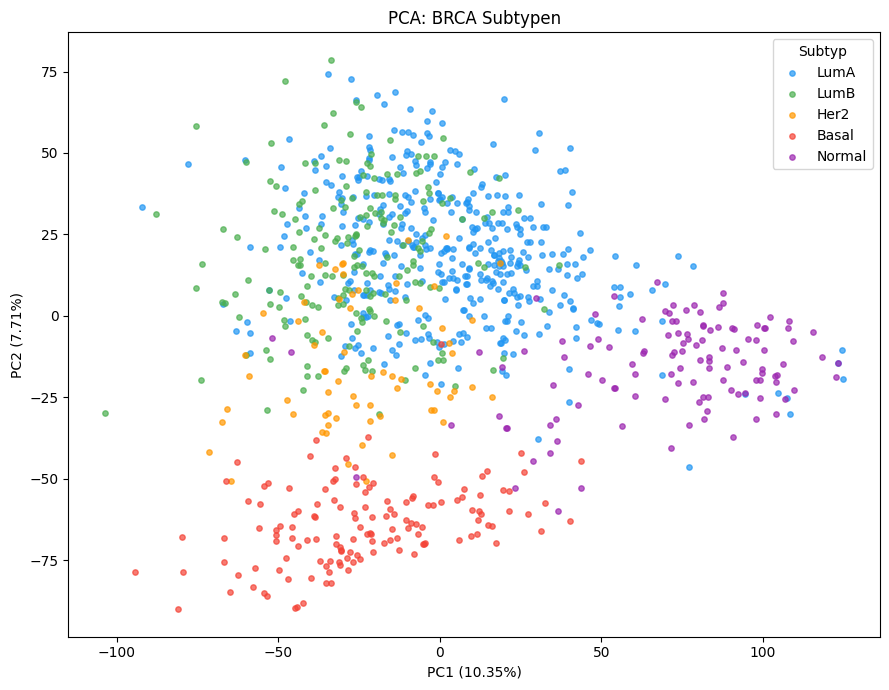

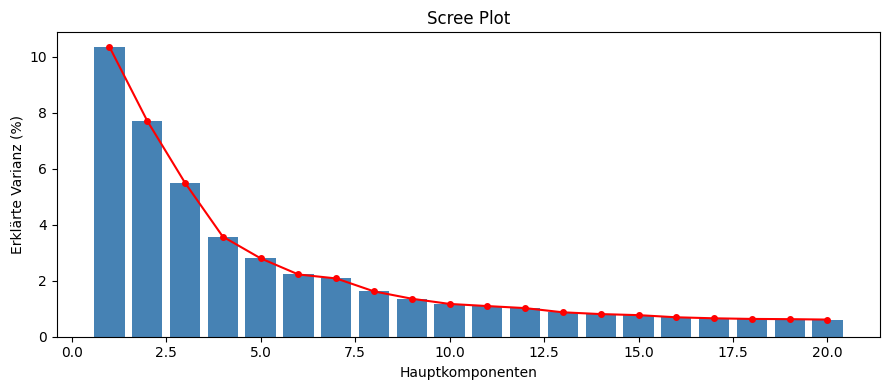

In [ ]:
#4.1 PCA durchführen und visualisieren
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#Daten vorbereiten und skalieren
#nur labeled samples verwenden, nur Expressionsspalten
combined_labeled = combined.dropna(subset=["BRCA_subtype"])

#für x fehlende Werte mit Spaltenmittelwerten ersetzen (PCA benötigt vollständige Daten)
x = combined_labeled[expression_cols].fillna(combined_labeled[expression_cols].mean())
y = combined_labeled["BRCA_subtype"].values

#Skalieren
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#PCA durchführen
pca = PCA(n_components=20)
x_pca = pca.fit_transform(x_scaled)

print(f"Erklärte Varianz PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Erklärte Varianz PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")

#PCA Plot (PC1 und PC2) nach Subtyp eingefärbt
subtype_colors = {
    "LumA": '#2196F3',
    "LumB": '#4CAF50',
    "Her2": '#FF9800',
    "Basal": '#F44336',
    "Normal": '#9C27B0'
}

fig, ax = plt.subplots(figsize = (9, 7))

for subtype, color in subtype_colors.items():
    mask = y == subtype
    ax.scatter(x_pca[mask, 0], x_pca[mask, 1], color = color, label = subtype, s = 15, alpha = 0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_title('PCA: BRCA Subtypen')
ax.legend(title='Subtyp')
plt.tight_layout()
plt.show()

#Scree Plot
fig, ax = plt.subplots(figsize = (9,4))

ax.bar(range(1,21), pca.explained_variance_ratio_ * 100, color = "steelblue")
ax.plot(range(1,21), pca.explained_variance_ratio_ *100, color = "red", marker = "o", markersize = 4)

ax.set_xlabel("Hauptkomponenten")
ax.set_ylabel("Erklärte Varianz (%)")
ax.set_title("Scree Plot")
plt.tight_layout()
plt.show()


--- Top 10 Gene PC1 (positiv) ---
ARHGAP20    0.021213
TNS1        0.021148
TGFBR2      0.021102
RBMS3       0.020718
LEPR        0.020663
PPP1R12B    0.020337
SH3D19      0.020285
FAT4        0.020145
SVEP1       0.020102
FOXO1       0.020075
Name: PC1, dtype: float64

--- Top 10 Gene PC1 (negativ) ---
C16orf59   -0.020358
PKMYT1     -0.020080
CENPM      -0.019773
UBE2C      -0.019711
TK1        -0.019675
UBE2T      -0.019639
LSM4       -0.019563
RNASEH2A   -0.019520
CKS2       -0.019507
UBE2S      -0.019416
Name: PC1, dtype: float64

--- Top 10 Gene PC2 (positiv) ---
TBC1D9    0.024155
ESR1      0.023795
THSD4     0.023167
MLPH      0.022908
XBP1      0.022710
FOXA1     0.022575
GPR77     0.022405
AGR3      0.022241
CA12      0.022225
RABEP1    0.022079
Name: PC2, dtype: float64

--- Top 10 Gene PC2 (negativ) ---
HAPLN3     -0.022983
B3GNT5     -0.022025
GLIPR2     -0.021893
FOXC1      -0.021752
C11orf75   -0.021661
FAM171A1   -0.021373
MTHFD1L    -0.021171
ART3       -0.020877
IL12

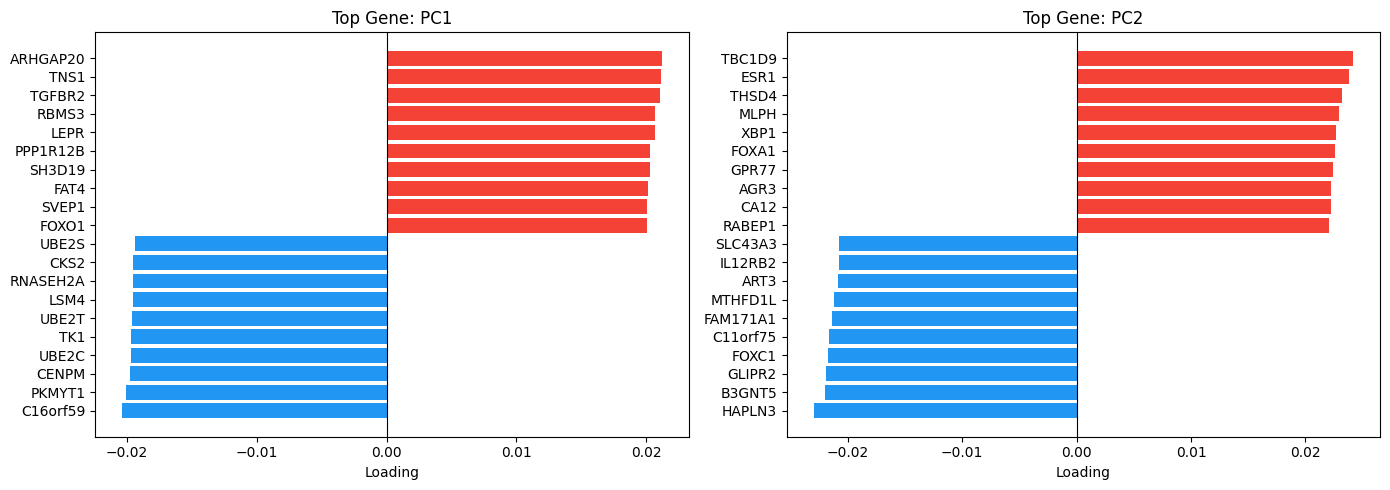

Gene die in PCA und Volcano Plot auftauchen: 29
{'SVEP1', 'RABEP1', 'GPR77', 'CT62', 'B3GNT5', 'FAT4', 'C11orf75', 'MLPH', 'TTC8', 'HAPLN3', 'C7orf58', 'EBF1', 'AGR3', 'FOXA1', 'CCDC125', 'XBP1', 'TBC1D9', 'PKMYT1', 'RUNDC1', 'GLIPR2', 'THSD4', 'ESR1', 'RUNX1T1', 'RBMS3', 'ARHGAP20', 'C16orf59', 'GATA3', 'CA12', 'FOXC1'}


In [ ]:
#4.2 Top-Gene der Hauptkomponenten identifizieren
#Loadings als Dataframe
loadings = pd.DataFrame(
    pca.components_.T,
    index = expression_cols,
    columns = [f"PC{i+1}" for i in range(20)]
)

#Top 10 Gene pro PC (positive und negative loadings)
for pc in ["PC1", "PC2"]:
    print(f"\n--- Top 10 Gene {pc} (positiv) ---")
    print(loadings[pc].nlargest(10))
    print(f"\n--- Top 10 Gene {pc} (negativ) ---")
    print(loadings[pc].nsmallest(10))

#Loadings visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, pc in enumerate(['PC1', 'PC2']):
    top10_pos = loadings[pc].nlargest(10)
    top10_neg = loadings[pc].nsmallest(10)
    top20 = pd.concat([top10_pos, top10_neg]).sort_values()

    colors = ['#F44336' if v > 0 else '#2196F3' for v in top20.values]
    axes[i].barh(top20.index, top20.values, color=colors)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'Top Gene: {pc}')
    axes[i].set_xlabel('Loading')

plt.tight_layout()
plt.show()

#Überlappung mit Ergebnissen aus 3.2 prüfen
#Top 20 Gene aus PC1 und PC2
top_pca_genes = set(loadings['PC1'].abs().nlargest(20).index) | \
                set(loadings['PC2'].abs().nlargest(20).index)

#Signifikante Gene aus Volcano Plot
sig_genes = set(sig["gene"].values)

#Überlappung
overlap = top_pca_genes & sig_genes
print(f"Gene die in PCA und Volcano Plot auftauchen: {len(overlap)}")
print(overlap)

In [ ]:
#Lasso-Modell (sklearn.linear_model.Lasso) um numerischen Outcome zu predicten

## 5: Forschungsfrage entwickeln 

### 5.1: Befunde zusammenfassen
- Was habe ich über die Datenstruktur gelernt?
- Welche Subtypen sind gut trennbar und welche nicht?
- Welche Gene tauchen in mehreren Analysen als relevant auf?

### 5.2 Beispielrichtungen für Forschungsfragen (von Claude AI)
- Klassifikation von Subtypen anhand von RNA-Seq
- Identifikation eines minimalen Gensets für die Subtyp-Unterschiedung
- Unterschiede in bestimmten biologischen Pfaden zwischen Subtypen

### 5.3 Clustering näher anschauen